
# Bayesian Hierarchical ARX Hurdle Model for Gravity Migration


**A. Hurdle (Bernoulli)** : 
$\text{logit}(P(\text{flow}>0)) = \alpha_d + X_h \beta_h + \beta_{lag} \text{is\_mig\_lag}$

**B. Volume (ARX)** : 
$$\log(\text{flow}) \sim \mathcal{N}(\mu_{d,t} + \phi_d (\text{lag} - \mu_{d,t-1}), \sigma_d)$$
$$\mu_{d,t} = \alpha_{V,d} + X \beta_{\text{grav}} + \beta_{\text{gdp}} \log(\text{gdpcap\_o}) + \beta_{\text{rich}} \text{is\_rich\_o}$$

**C. Variance (Geo)** : 
$\sigma_d \sim \text{HalfNormal}(\sigma_{\text{cluster}}[\text{continent\_origine}[d]])$ *(alternative à InverseGamma)*


# MÉTHODOLOGIE 
*(pour rapport ou annexe)*

1) Couplage entre bayésien & Machine Learning (Partie ARX et Variance Géo).  
Ce modèle bayésien intègre les découvertes faites par le Random Forest :
- Saut brutal de migration autour de 18 000 $ de PIB/hab. 
  Encodé par la variable indicatrice 'is_rich_o' 
- Interaction 'log_D_ij * LB_ij' (distance * frontière commune) 
  dont l'importance a été découverte par un PDP 2D du Random forest, et prouvée par régression linéaire 
- Correction des résidus : La cartographie des erreurs des XGBoost & RF montrait une incertitude 
  systématique (sous/sur-estimation) en Afrique, et un peu en Asie/Amerique latine. L'hétéroscédasticité 
  géographique modélise cette variance propre à chaque continent (à affiner par zone géo plus précise?)


2) Gestion des zéros (partie Hurdle). 
Le problème: il y a beaucoup de flux nuls, et on ne peut ni les enlever de l'analyse, ni faire log(x+1) (scientifiquement mauvais)
Forcer un pic à zéro pour loi Normale (qui ne sait faire que une cloche, et pas une cloche + un pic à zéro) fait diverger 
la variance et les chaines de Markov. 
Le modèle Hurdle: regression logistique (Bernoulli); si et seulement si le couloir est ouvert (>0) => équation de gravité ARX. 
Si non (flux=0) STAN s'arrête là et prédit 0 migrant (dans la phase de prédiction)



3) intuition physique de STAN (Hamiltonian Monte Carlo). 
Contrairement aux auteurs qui utilisaient le Gibbs sampling via JAGS, Stan utilise HMC. 
 HMC utilise la mécanique hamiltonienne pour explorer le paysage des posteriors bayésiens, (trajectoire guidée par lmes équations de Hamilton)
avec une étape d'acceptation Metropolis-Hastings à la fin selon $$P(\text{acceptation}) = \min(1, \exp(-\Delta H))$$ 
pour corriger les erreurs numériques sur la conservation de l'énergie ($$\Delta H =0$$) liées à la discrétisation de temporelle. 


Une exploration entière par Metropolis (marche aléatoire) aurait été inefficace et incroyablement lente pour autant de paramètres

4) Stabilité géométrique.  
Pour éviter que l'algorithme ne se coince (entonnoir), au lieu d'échantillonner 
directement α_d ~ N(μ, τ), on échantillonne un bruit pur ε ~ N(0,1), puis on calcule 
 α_d = μ + τ·ε. Cela détruit les corrélations pathologiques durant le HMC 

5) Approche dyadique.  
Mon modèle est purement "Dyadique" contrairement à celui de Ishagh (Inflow/Outflow). Ce code modélise chaque couloir de migration.  
On pourra comparer les deux approches in fine. 

6) Évaluation Out-Of-Sample.  
Le modèle est entraîné sur la période 1990-2010 et testé en prédiction pure sur 2015. 
Pour évaluer la qualité de la prédiction, on retient la MAE (Erreur absolue en nombre d'humains réels) et le WMAPE 
(Weighted Mean Absolute Percentage Error), qui pondére l'erreur par la taille du 
flux pour éviter l'explosion mathématique des pourcentages sur les couloirs proches de zéro.


In [ ]:
# Installation des bibliothèques non classiqus
!pip install pycountry_convert arviz cmdstanpy

# compilation de Stan
import cmdstanpy
cmdstanpy.install_cmdstan()

/opt/anaconda3/envs/datasci/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
09:51:16 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]

09:58:57 - cmdstanpy - INFO - CmdStan done processing.
09:58:58 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter[1] is 0, but must be positive! (in 'HMC_ARX.stan', line 129, column 2 to column 49)
Exception: normal_lpdf: Scale parameter[16] is 0, but must be positive! (in 'HMC_ARX.stan', line 129, column 2 to column 49)
Consider re-running with show_console=True if the above output is unclear!



                     Mean      MCSE    StdDev       MAD        5%       50%  \
alpha_global    -2.369720  0.002196  0.174167  0.172825 -2.658780 -2.368640   
tau_alpha        0.138739  0.001530  0.108401  0.103186  0.010689  0.114406   
beta_lag_global  6.662920  0.002548  0.225219  0.221907  6.298940  6.658400   
mu_intercept     9.932580  0.008899  0.529269  0.512428  9.115400  9.891030   
tau_mu           0.315506  0.005490  0.248352  0.234832  0.022584  0.259338   
phi_global       0.947519  0.000111  0.006577  0.006618  0.936433  0.947681   

                       95%  ESS_bulk  ESS_tail  ESS_bulk/s    R_hat  
alpha_global     -2.087050   6337.98   5618.52     7.89781  1.00112  
tau_alpha         0.350578   4258.93   3880.07     5.30709  1.00081  
beta_lag_global   7.042830   7879.28   6720.32     9.81843  1.00019  
mu_intercept     10.851600   3622.14   4977.53     4.51357  1.00065  
tau_mu            0.812807   2037.24   3511.48     2.53862  1.00084  
phi_global        0.95805

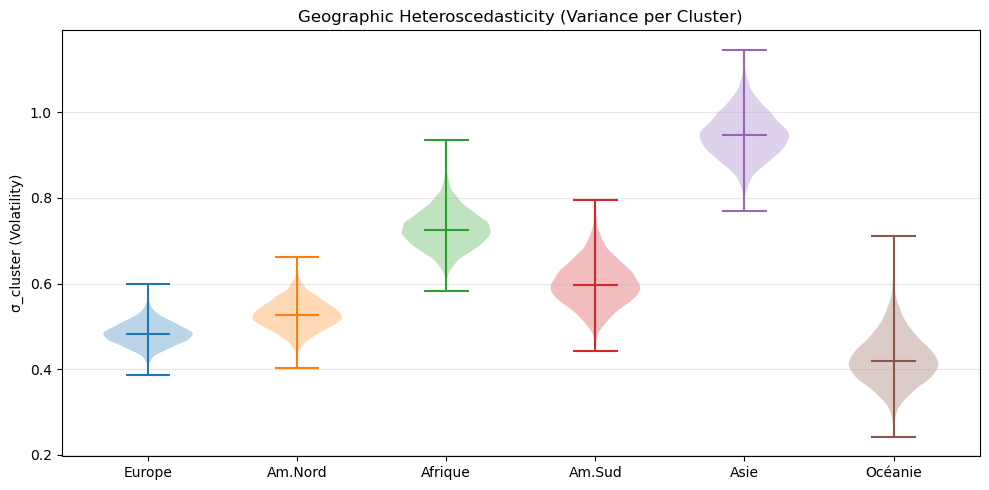

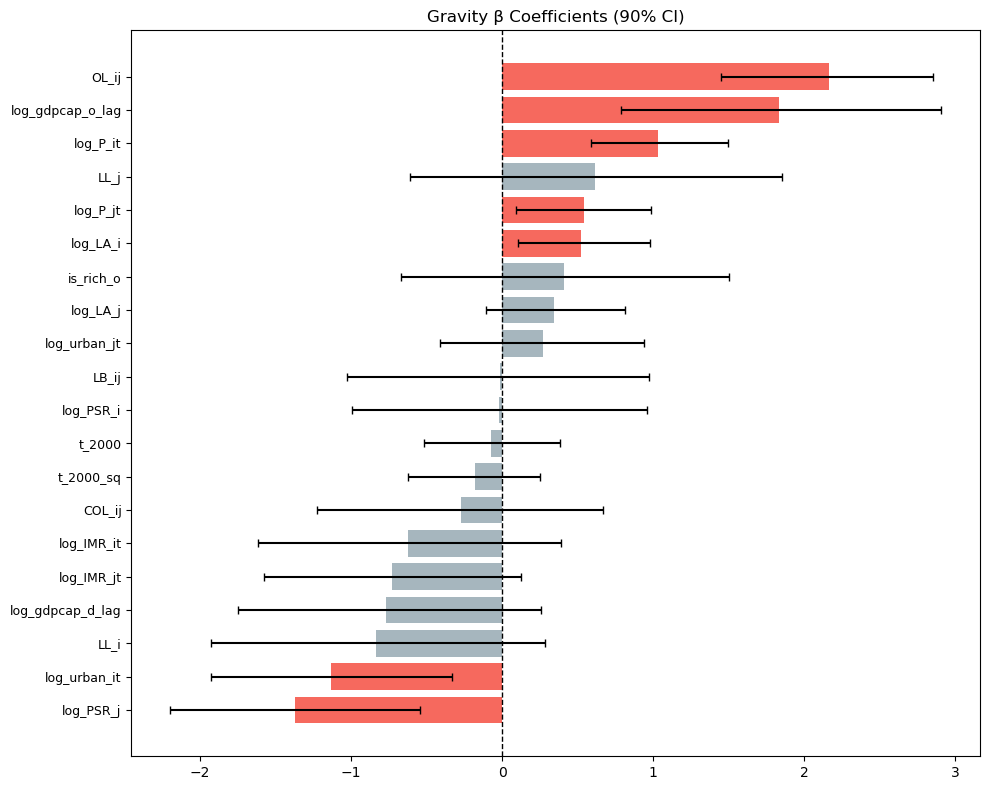

OOS Hurdle Accuracy (Binary Open/Close): 98.0%
OOS Conditional MAE (True > 0 only)    : 10926 migrants
OOS GLOBAL WMAPE (Weighted Percentage) : 29.1 %
OOS GLOBAL MAE (All dyads)             : 8988 migrants
OOS GLOBAL Log-MAE (For ML comparison) : 0.505


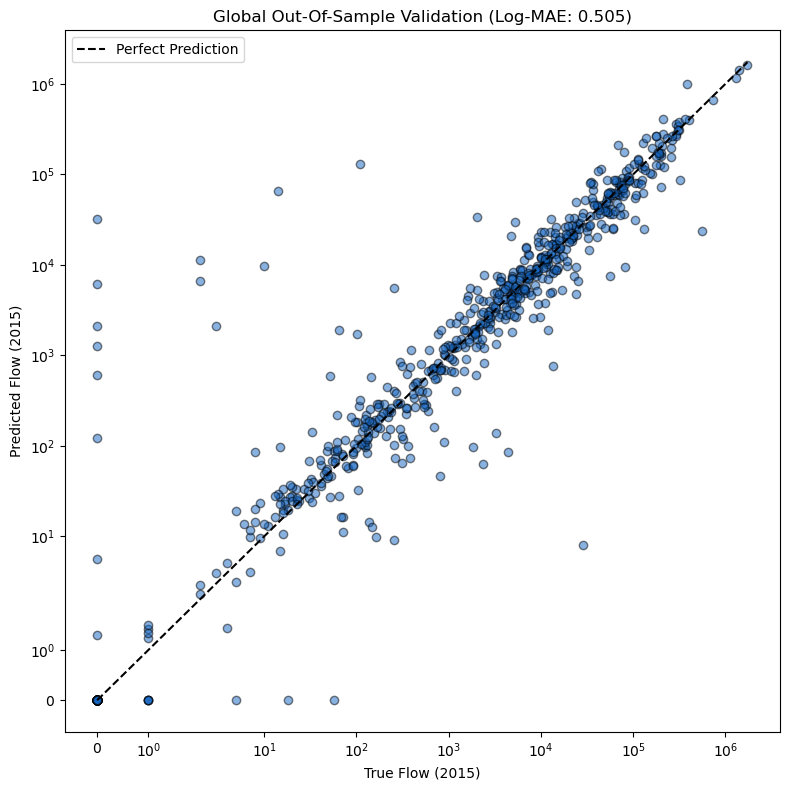

In [ ]:


import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import pycountry_convert as pc
from cmdstanpy import CmdStanModel
from sklearn.metrics import accuracy_score


warnings.filterwarnings('ignore')
np.random.seed(42)


#BLOC POUR TESTER SUR QUELQUES PAYS



# 1. uniquement pour le sanity check (sur quelques pays seulement)



DATA_PATH = "../data/data_final/DF_GRAVITY_sans_NaN.csv"
df_main = pd.read_csv(DATA_PATH)

"""
# Selection de 32 pays 

PAYS_NORD = ['FRA', 'USA', 'ESP', 'CAN', 'DEU', 'GBR', 'ITA', 'AUS', 'CHE']
PAYS_AFRIQUE = ['DZA', 'RWA', 'ZAF', 'NER', 'NGA', 'COD', 'SOM', 'MAR', 'EGY']
PAYS_AMLAT = ['HTI', 'MEX', 'VEN', 'COL', 'BRA', 'SLV']
PAYS_ASIE = ['MMR', 'IND', 'CHN', 'SYR', 'AFG', 'PAK', 'PHL', 'BGD']

PAYS_TEST = PAYS_NORD + PAYS_AFRIQUE + PAYS_AMLAT + PAYS_ASIE

df = df_main[
    df_main['orig'].isin(PAYS_TEST) &
    df_main['dest'].isin(PAYS_TEST) &
    (df_main['orig'] != df_main['dest'])
].copy()
df = df.sort_values(['orig', 'dest', 'year']).reset_index(drop=True)

"""

# Sélection de 66 pays

PAYS_NORD = ['FRA', 'USA', 'ESP', 'CAN', 'DEU', 'GBR', 'ITA', 'AUS', 'CHE', 
             'JPN', 'KOR', 'NLD', 'SWE', 'BEL', 'AUT', 'POL', 'NZL']
PAYS_AFRIQUE = ['DZA', 'RWA', 'ZAF', 'NER', 'NGA', 'COD', 'SOM', 'MAR', 'EGY', 
                'SEN', 'CIV', 'KEN', 'ETH', 'GHA', 'AGO', 'TUN', 'CMR']
PAYS_AMLAT = ['HTI', 'MEX', 'VEN', 'COL', 'BRA', 'SLV', 
              'ARG', 'CHL', 'PER', 'ECU', 'CUB', 'DOM', 'GTM', 'BOL', 'URY']
PAYS_ASIE = ['MMR', 'IND', 'CHN', 'SYR', 'AFG', 'PAK', 'PHL', 'BGD', 
             'VNM', 'THA', 'IDN', 'MYS', 'IRN', 'SAU', 'TUR', 'IRQ', 'ARE']

PAYS_TEST = PAYS_NORD + PAYS_AFRIQUE + PAYS_AMLAT + PAYS_ASIE

# Filtrage du dataset
df = df_main[
    df_main['orig'].isin(PAYS_TEST) &
    df_main['dest'].isin(PAYS_TEST) &
    (df_main['orig'] != df_main['dest'])
].copy()
df = df.sort_values(['orig', 'dest', 'year']).reset_index(drop=True)

"""
# 1. Data Loading (Full World Dataset)




DATA_PATH = "../data/data_final/DF_GRAVITY_sans_NaN.csv"
df_main = pd.read_csv(DATA_PATH)

# On conserve toutes les dyades internationales (origine != destination)
df = df_main[df_main['orig'] != df_main['dest']].copy()

# Tri indispensable pour la cohérence des séries temporelles (Lags AR1)
df = df.sort_values(['orig', 'dest', 'year']).reset_index(drop=True)

print(f"Nombre total de lignes chargées : {len(df)}")
print(f"Nombre de pays uniques : {len(df['orig'].unique())}")

"""



# 2. Geographic Clustering (Heteroscedasticity component)





def get_continent_id(iso3_code):
    """Maps ISO3 country codes to continent ID for Stan variance clustering."""
    try:
        iso2 = pc.country_alpha3_to_country_alpha2(iso3_code)
        continent = pc.country_alpha2_to_continent_code(iso2)
        mapping = {'EU': 1, 'NA': 2, 'AF': 3, 'SA': 4, 'AS': 5, 'OC': 6}
        return mapping.get(continent, 7)
    except Exception:
        return 7 

df['continent_orig'] = df['orig'].apply(get_continent_id)
K_clusters = 6





# 3. Features &  Lags





# Hurdle & Volume indicators
df['is_migration'] = (df['flow'] > 0).astype(int)
df['log_flow'] = np.where(df['flow'] > 0, np.log(df['flow']), np.nan)

# ML Threshold interaction
SEUIL_LOG_GDP = 2.9
df['is_rich_o'] = (df['log_gdpcap_o_lag'] > SEUIL_LOG_GDP).astype(float)

# Hurdle spatial interaction
df['log_D_ij'] = np.log(df['D_ij'].replace(0, np.nan))
df['logD_times_LB'] = df['log_D_ij'] * df['LB_ij']

# Lags (AR1 structure)
df['dyad'] = df['orig'] + "_" + df['dest']
df['is_mig_lag'] = df.groupby('dyad')['is_migration'].shift(1)
df['log_flow_lag'] = df.groupby('dyad')['log_flow'].shift(1)

df = df.dropna(subset=['is_mig_lag']).reset_index(drop=True)





# 4. Variable Definition & Train/Test Split






HURDLE_VARS = ['log_D_ij', 'LB_ij', 'logD_times_LB']
ML_VARS = ['log_gdpcap_o_lag', 'is_rich_o']

GRAVITY_VARS_RAW = [
    'P_it', 'P_jt', 'PSR_i', 'PSR_j', 'IMR_it', 'IMR_jt', 
    'urban_it', 'urban_jt', 'LA_i', 'LA_j'
]
GRAVITY_VARS_BIN = ['LL_i', 'LL_j', 'LB_ij', 'OL_ij', 'COL_ij', 't_2000', 't_2000_sq', 'log_gdpcap_d_lag']

# Log transformations for continuous gravity variables
for raw in GRAVITY_VARS_RAW:
    df[f'log_{raw}'] = np.log(df[raw].replace(0, np.nan))

X_VOL_COLS = [f'log_{v}' for v in GRAVITY_VARS_RAW] + GRAVITY_VARS_BIN + ML_VARS
K_grav, K_h = len(X_VOL_COLS), len(HURDLE_VARS)

# Temporal Split OOS (Out-Of-Sample)
df_train = df[df['year'] <= 2010].copy()
df_test  = df[df['year'] == 2015].copy()
df = df_train 






# 5. Missing Values & Matrix Separation






HURDLE_REQUIRED = HURDLE_VARS + ['is_mig_lag', 'is_migration', 'dyad', 'continent_orig']
df_hurdle = df.dropna(subset=HURDLE_REQUIRED).copy().reset_index(drop=True)

VOLUME_REQUIRED = X_VOL_COLS + ['log_flow', 'log_flow_lag', 'dyad', 'continent_orig']
df_volume = df[df['flow'] > 0].dropna(subset=VOLUME_REQUIRED).copy().reset_index(drop=True)

N_h, N_v = len(df_hurdle), len(df_volume)







# 6. Dyad Encoding & Standardization






dyades_h = sorted(df_hurdle['dyad'].unique())
dyad_to_h = {d: i+1 for i, d in enumerate(dyades_h)}
df_hurdle['dyad_id_h'] = df_hurdle['dyad'].map(dyad_to_h)
D_h = len(dyades_h)

cluster_h = df_hurdle.groupby('dyad')['continent_orig'].first().reindex([k for k,v in sorted(dyad_to_h.items(), key=lambda item: item[1])]).values.astype(int)

dyades_v = sorted(df_volume['dyad'].unique())
dyad_to_v = {d: i+1 for i, d in enumerate(dyades_v)}
df_volume['dyad_id_v'] = df_volume['dyad'].map(dyad_to_v)
D_v = len(dyades_v)

cluster_v = df_volume.groupby('dyad')['continent_orig'].first().reindex([k for k,v in sorted(dyad_to_v.items(), key=lambda item: item[1])]).values.astype(int)

# Standardization logic
BINARY_COLS_VOL = ['LL_i', 'LL_j', 'LB_ij', 'OL_ij', 'COL_ij', 'is_rich_o']
BINARY_COLS_HUR = ['LB_ij']

def standardize_matrix(X, col_names, binary_cols, fit_stats=None):
    """Standardizes continuous features, bypassing binary flags."""
    X_std = X.copy().astype(float)
    stats = {}
    for j, col in enumerate(col_names):
        if col not in binary_cols:
            mu = X[:, j].mean() if fit_stats is None else fit_stats[col]['mean']
            sd = X[:, j].std()  if fit_stats is None else fit_stats[col]['std']
            sd = sd if sd > 1e-8 else 1.0
            X_std[:, j] = (X[:, j] - mu) / sd
            stats[col] = {'mean': mu, 'std': sd}
        else:
            stats[col] = {'mean': 0.0, 'std': 1.0}
    return X_std, stats

X_vol_std, stats_vol = standardize_matrix(df_volume[X_VOL_COLS].values, X_VOL_COLS, BINARY_COLS_VOL)
X_h_std, stats_h = standardize_matrix(df_hurdle[HURDLE_VARS].values, HURDLE_VARS, BINARY_COLS_HUR)








# 7. Out-Of-Sample (OOS) Test Preparation








df_test['dyad_id_test'] = df_test['dyad'].map(dyad_to_h)
df_test['dyad_id_test_v'] = df_test['dyad'].map(dyad_to_v).fillna(0).astype(int)
df_test = df_test.dropna(subset=['dyad_id_test']).copy()

log_flow_lag_test = df_test['log_flow_lag'].fillna(0.0).values
is_mig_lag_test = df_test['is_mig_lag'].fillna(0.0).values

X_test_v_std, _ = standardize_matrix(df_test[X_VOL_COLS].values, X_VOL_COLS, BINARY_COLS_VOL, fit_stats=stats_vol)
X_test_h_std, _ = standardize_matrix(df_test[HURDLE_VARS].values, HURDLE_VARS, BINARY_COLS_HUR, fit_stats=stats_h)








# 8. Stan Dictionary Formulation








stan_data = {
    'N_h': int(N_h), 'D_h': int(D_h), 'K_h': int(K_h),
    'dyad_id_h': df_hurdle['dyad_id_h'].astype(int).tolist(),
    'is_mig': df_hurdle['is_migration'].astype(int).tolist(),
    'is_mig_lag': df_hurdle['is_mig_lag'].astype(float).tolist(),
    'X_h': X_h_std.tolist(),
    'cluster_h': cluster_h.tolist(),

    'N_v': int(N_v), 'D_v': int(D_v), 'K_v': int(K_grav),
    'dyad_id_v': df_volume['dyad_id_v'].astype(int).tolist(),
    'log_flow': df_volume['log_flow'].astype(float).tolist(),
    'log_flow_lag': df_volume['log_flow_lag'].astype(float).tolist(),
    'X_v': X_vol_std.tolist(),
    'cluster_v': cluster_v.tolist(),

    'K_clusters': int(K_clusters),

    'N_test': len(df_test),
    'dyad_id_test': df_test['dyad_id_test'].astype(int).tolist(),
    'X_h_test': X_test_h_std.tolist(),
    'is_mig_lag_test': is_mig_lag_test.tolist(),
    'X_v_test': X_test_v_std.tolist(),
    'log_flow_lag_test': log_flow_lag_test.tolist(),
    'dyad_id_test_v': df_test['dyad_id_test_v'].tolist(),
}








# 9. Stan Sampling










STAN_FILE = "../STAN/HMC_ARX.stan"
model = CmdStanModel(stan_file=STAN_FILE)

fit = model.sample(
    data=stan_data,
    chains=4,
    parallel_chains=2,
    iter_warmup=1500,
    iter_sampling=1500,
    save_warmup=False,
    seed=42,
    thin=4,
    adapt_delta=0.98,
    max_treedepth=12,
    show_progress=True,
    output_dir="./stan_outputs"
)

# Optional CLI summary print
print(fit.summary().loc[['alpha_global', 'tau_alpha', 'beta_lag_global', 'mu_intercept', 'tau_mu', 'phi_global']])







# 10. Visualizations & Diagnostics







idata = az.from_cmdstanpy(
    posterior=fit,
    log_likelihood={'hurdle': 'log_lik_h', 'volume': 'log_lik_v'},
    posterior_predictive={'is_mig_hat': 'is_mig_hat', 'log_flow_hat': 'log_flow_hat'},
)

CONTINENT_NAMES = {1:'Europe', 2:'Am.Nord', 3:'Afrique', 4:'Am.Sud', 5:'Asie', 6:'Océanie'}

# Variance by continent (Heteroskedasticity)
fig, ax = plt.subplots(figsize=(10, 5))


if 'sigma_cluster' in idata.posterior:
    #
    sigma_draws = idata.posterior['sigma_cluster'].values 
    
    for k in range(1, K_clusters+1):
        # le cluster 'k' est à 'k-1'
        draws_k = sigma_draws[..., k-1].flatten()
        ax.violinplot(draws_k, positions=[k], widths=0.6, showmedians=True)

ax.set_xticks(range(1, K_clusters+1))
ax.set_xticklabels([CONTINENT_NAMES.get(k, f'C{k}') for k in range(1, K_clusters+1)])
ax.set_ylabel("σ_cluster (Volatility)")
ax.grid(True, alpha=0.3, axis='y')
plt.title("Geographic Heteroscedasticity (Variance per Cluster)")
plt.tight_layout()
plt.savefig('variance_cluster.pdf', bbox_inches='tight')
plt.show()

# Gravity Coefficients Forest Plot
if 'beta_grav' in idata.posterior:
    beta_flat = idata.posterior['beta_grav'].values.reshape(-1, K_grav)
    beta_means = beta_flat.mean(axis=0)
    beta_q05, beta_q95 = np.percentile(beta_flat, [5, 95], axis=0)

    order = np.argsort(beta_means)
    fig, ax = plt.subplots(figsize=(10, max(6, K_grav * 0.4)))
    colors_coef = ['#F44336' if beta_q05[i] > 0 or beta_q95[i] < 0 else '#90A4AE' for i in order]
    
    ax.barh(range(K_grav), beta_means[order], xerr=[beta_means[order]-beta_q05[order], beta_q95[order]-beta_means[order]], color=colors_coef, alpha=0.8, capsize=3)
    ax.set_yticks(range(K_grav))
    ax.set_yticklabels([X_VOL_COLS[i] for i in order], fontsize=9)
    ax.axvline(0, color='black', lw=1, linestyle='--')
    plt.title("Gravity β Coefficients (90% CI)")
    plt.tight_layout()
    plt.savefig('gravity_coefficients.pdf', bbox_inches='tight')
    plt.show()






# 11. Out-of-Sample Performance Evaluation (2015 test)







y_true_test = df_test['flow'].values
y_pred_test = np.median(fit.stan_variable('flow_test_hat'), axis=0)

# A. Hurdle Accuracy (Binary classification)
y_true_bin = (y_true_test > 0).astype(int)
y_pred_bin = (y_pred_test > 0).astype(int)
acc = accuracy_score(y_true_bin, y_pred_bin)
print(f"OOS Hurdle Accuracy (Binary Open/Close): {acc*100:.1f}%")

# B. Conditional Volume MAE (Only where true flow > 0)
mask_positive = y_true_test > 0
y_true_pos = y_true_test[mask_positive]
y_pred_pos = y_pred_test[mask_positive]
cond_mae = np.mean(np.abs(y_true_pos - y_pred_pos))
print(f"OOS Conditional MAE (True > 0 only)    : {cond_mae:.0f} migrants")

# C. GLOBAL Performance (All dyads, penalizing false positives/negatives)
global_mae = np.mean(np.abs(y_true_test - y_pred_test))
# WMAPE (Weighted Mean Absolute Percentage Error)
global_wmape = np.sum(np.abs(y_true_test - y_pred_test)) / np.sum(y_true_test) * 100

print(f"OOS GLOBAL WMAPE (Weighted Percentage) : {global_wmape:.1f} %")
#  log(1 + x) to safely handle true zeros
global_log_mae = np.mean(np.abs(np.log1p(y_true_test) - np.log1p(y_pred_test)))

print(f"OOS GLOBAL MAE (All dyads)             : {global_mae:.0f} migrants")
print(f"OOS GLOBAL Log-MAE (For ML comparison) : {global_log_mae:.3f}")

# Actual vs Predicted Scatter (Log Scale)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_true_test, y_pred_test, alpha=0.5, color='#1565C0', edgecolors='k')
lim = [0, max(y_true_test.max(), y_pred_test.max())]
ax.plot(lim, lim, 'k--', label='Perfect Prediction')
ax.set_xscale('symlog')
ax.set_yscale('symlog')
ax.set_xlabel('True Flow (2015)')
ax.set_ylabel('Predicted Flow (2015)')
ax.legend()
plt.title(f'Global Out-Of-Sample Validation (Log-MAE: {global_log_mae:.3f})')
plt.tight_layout()
plt.savefig('prediction_scatter.pdf', bbox_inches='tight')
plt.show()

Figure 1: le Graal, ce serait des formes étalées horizontalement, basses sur l'axe des Y (modèle sûr de lui + volatilité basse). 
Figure 2: 